<a href="https://colab.research.google.com/github/andr322a/Machine-Learning-for-Business-Intelligence/blob/main/ML4BI_E3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning for BI 2

## Deep Learning exercises for week 3

In this exercise, you'll practice on the examples we went through during the lectures.

Try one or more!

1. You used two representation layers before the final classification layer. Try using one or three representation layers, and see how doing so affects validation and test accuracy

2. Try using layers with more units or fewer units: 32 units, 64 units, and so on.

**Loading the IMDB dataset**

In [5]:
from tensorflow.keras.datasets import imdb
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(
    num_words=10000)

**Encoding the integer sequences via multi-hot encoding**

In [2]:
import numpy as np
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        for j in sequence:
            results[i, j] = 1.
    return results
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

In [3]:
y_train = np.asarray(train_labels).astype("float32")
y_test = np.asarray(test_labels).astype("float32")

### Building your model

In [6]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

In [7]:
model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

In [8]:
x_val = x_train[:10000]
partial_x_train = x_train[10000:]
y_val = y_train[:10000]
partial_y_train = y_train[10000:]

In [9]:
history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val),
                    verbose=0)

In [11]:
# We can also se the error rate
results = model.evaluate(x_test, y_test)


782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8642 - loss: 0.6567


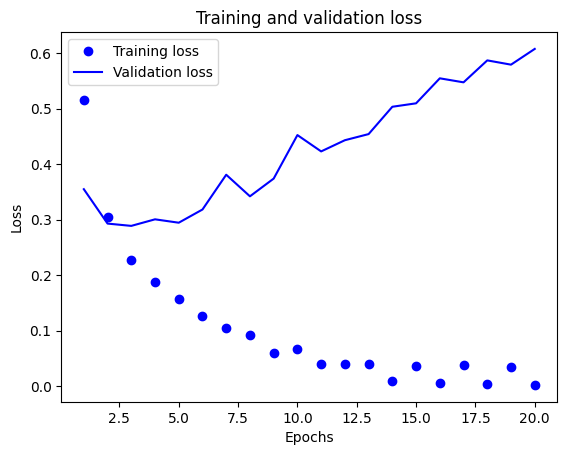

In [10]:
import matplotlib.pyplot as plt
history_dict = history.history
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, "bo", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Newswire

### Information bottleneck

Try creating an information bottleneck in your architecture. For example, you can this by using 64 neurons in the first layer and 4 neurons in the second.

Try different types of configurations and see how the validation loss or accuracy curve is affected. Write a function that allows to change the number of neurons in each layer and then make a joint plot of all the curves afterwards.

I have copied in the data loading and labels encoding steps from the course notebook to help you get started.

**Loading the Reuters dataset**

In [23]:
from tensorflow.keras.datasets import reuters
(train_data, train_labels), (test_data, test_labels) = reuters.load_data(
    num_words=10000)

**Decoding newswires back to text**

In [24]:
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

**Encoding the labels**

In [25]:
def to_one_hot(labels, dimension=46):
    results = np.zeros((len(labels), dimension))
    for i, label in enumerate(labels):
        results[i, label] = 1.
    return results
y_train = to_one_hot(train_labels)
y_test = to_one_hot(test_labels)

In [26]:
from tensorflow.keras.utils import to_categorical
y_train = to_categorical(train_labels)
y_test = to_categorical(test_labels)

**Setting aside a validation set**

In [27]:
x_val = x_train[:1000]
partial_x_train = x_train[1000:]
y_val = y_train[:1000]
partial_y_train = y_train[1000:]

### Building your model

In [28]:
from tensorflow import keras
from tensorflow.keras import layers
model = keras.Sequential([
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(46, activation="softmax")
])

In [29]:
model.compile(optimizer="rmsprop",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

In [30]:
# model fit
history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val),
                    verbose=1)

# Error rate
results = model.evaluate(x_test, y_test)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.5249 - loss: 2.7084 - val_accuracy: 0.6280 - val_loss: 1.8441
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.6864 - loss: 1.5403 - val_accuracy: 0.6910 - val_loss: 1.3841
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.7434 - loss: 1.1804 - val_accuracy: 0.7360 - val_loss: 1.1997
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.7907 - loss: 0.9696 - val_accuracy: 0.7620 - val_loss: 1.0927
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.8256 - loss: 0.8067 - val_accuracy: 0.7600 - val_loss: 1.0539
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.8552 - loss: 0.6728 - val_accuracy: 0.7990 - val_loss: 0.9788
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.8841 - loss: 0.5628 - val_accuracy: 0.8060 - val_loss: 0.9391
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.9018 - loss: 0.4751 - val_accuracy: 0.8260 - v

### F1-score and imbalance

Retrain the model from scratch on the train and validation data combined for nine epochs, but this time compute the test set F1-score and compare it to the test set accuracy.

In [35]:
from sklearn.metrics import f1_score
import numpy as np

# Redefine model from scratch
model = keras.Sequential([
    layers.Dense(256, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(46, activation="softmax")
])

model.compile(optimizer="rmsprop",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

# Train on full data (x_train, y_train) for 9 epochs
model.fit(x_train, y_train, epochs=9, batch_size=512, verbose=1)

# Evaluate on test set
results = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {results[1]:.4f}")

# Compute F1-score
predictions = model.predict(x_test)
# Convert one-hot predictions and labels back to class integers
y_pred = np.argmax(predictions, axis=1)
y_true = np.argmax(y_test, axis=1)

f1 = f1_score(y_true, y_pred, average='weighted')
print(f"Test F1-score (weighted): {f1:.4f}")

Epoch 1/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 121ms/step - accuracy: 0.5278 - loss: 2.1445
Epoch 2/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 155ms/step - accuracy: 0.7242 - loss: 1.2048
Epoch 3/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 158ms/step - accuracy: 0.7850 - loss: 0.9244
Epoch 4/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - accuracy: 0.8362 - loss: 0.7094
Epoch 5/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step - accuracy: 0.8789 - loss: 0.5326
Epoch 6/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step - accuracy: 0.9093 - loss: 0.4005
Epoch 7/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - accuracy: 0.9148 - loss: 0.3655
Epoch 8/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 169ms/step - accuracy: 0.9407 - loss: 0.2598
Epoch 9/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 119ms/step - accuracy: 0.9449 - loss: 0.2239
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7471 - loss: 1.1755
Test Accuracy: 0.7471
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Test F1-score (weighted): 0.7311
